### Import librairie

In [1]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import json
import networkx as nx


c:\Users\dav-9\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Import datas

In [2]:
# Download latest version
path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")

print("Path to dataset files:", path)
print("Fichiers dans le dossier :")
print(os.listdir(path))

Path to dataset files: C:\Users\dav-9\.cache\kagglehub\datasets\tmdb\tmdb-movie-metadata\versions\2
Fichiers dans le dossier :
['tmdb_5000_credits.csv', 'tmdb_5000_movies.csv']


### Read in pandas

In [3]:
file_path_movie = os.path.join(path, "tmdb_5000_movies.csv")
file_path_credits = os.path.join(path, "tmdb_5000_credits.csv")

movies   = pd.read_csv(file_path_movie)
credits  = pd.read_csv(file_path_credits)

# Vérifier les colonnes
print(credits.columns)
print(movies.columns)

# Faire la jointure sur movie_id (credits) et id (movies)
data = movies.merge(credits, left_on='id', right_on='movie_id', how='inner')

print(data.shape)
col = data.columns.tolist()
for i in range(0, len(col), 5) :
    if (i + 5 <= len(col)) :
        print(col[i : i + 5])
    else :
        print(col[i:])
print(data.head())

Index(['movie_id', 'title', 'cast', 'crew'], dtype='object')
Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')
(4803, 24)
['budget', 'genres', 'homepage', 'id', 'keywords']
['original_language', 'original_title', 'overview', 'popularity', 'production_companies']
['production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages']
['status', 'tagline', 'title_x', 'vote_average', 'vote_count']
['movie_id', 'title_y', 'cast', 'crew']
      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam.

### Info dataset

=== Film le plus ancien ===
Titre     : Intolerance
Date      : 1916-09-04
Budget    : $385,907
Note      : 7.4/10

=== Film le plus récent ===
Titre     : Growing Up Smith
Date      : 2017-02-03
Budget    : $0
Note      : 7.4/10


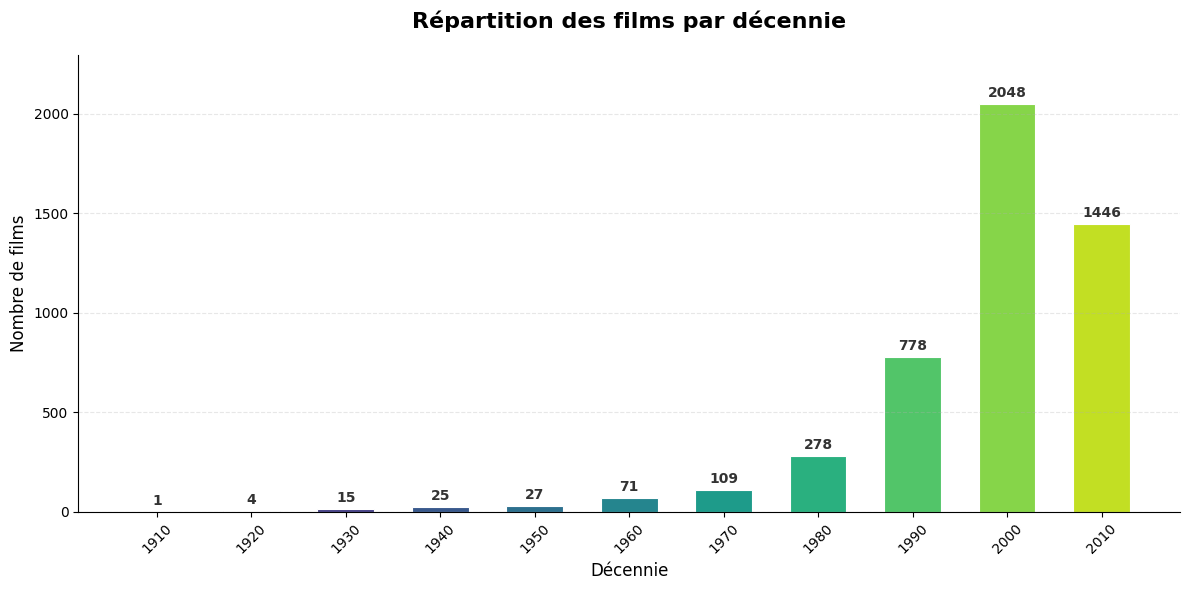

Nombre de films sans date : 1
title_x                   : America Is Still the Place
budget                    : 0
revenue                   : 0
vote_average              : 0.0
vote_count                : 0
original_language         : en
status                    : Released
overview                  : 1971 post civil rights San Francisco seemed like the perfect place for a black Korean War veteran and his family to realize their dream of economic independence and his own chance to be his a "boss". Charlie Walker would soon find out how naive he was. In a city full of impostors and naysayers, he refused to take "No" for an answer. Until a catastrophic disaster opened a door that had never been open to a black man before. This is a story about what happened when he stepped through that door, with both feet!.


In [4]:
# Convertir release_date en datetime
data['release_date'] = pd.to_datetime(data['release_date'], errors='coerce')

# Film le plus ancien et le plus récent
oldest = data.loc[data['release_date'].idxmin()]
newest = data.loc[data['release_date'].idxmax()]

print("=== Film le plus ancien ===")
print(f"Titre     : {oldest['title_x']}")
print(f"Date      : {oldest['release_date'].date()}")
print(f"Budget    : ${oldest['budget']:,}")
print(f"Note      : {oldest['vote_average']}/10")

print("\n=== Film le plus récent ===")
print(f"Titre     : {newest['title_x']}")
print(f"Date      : {newest['release_date'].date()}")
print(f"Budget    : ${newest['budget']:,}")
print(f"Note      : {newest['vote_average']}/10")

# Répartition par décennie
data['decade'] = (data['release_date'].dt.year // 10 * 10).astype('Int64')
decade_counts = data['decade'].value_counts().sort_index().dropna()

fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.viridis([i / len(decade_counts) for i in range(len(decade_counts))])
bars = ax.bar(decade_counts.index.astype(str), decade_counts.values, color=colors, width=0.6, edgecolor='white', linewidth=0.8)

# Valeurs au dessus des barres
for bar, val in zip(bars, decade_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333')

ax.set_title('Répartition des films par décennie', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Décennie', fontsize=12)
ax.set_ylabel('Nombre de films', fontsize=12)
ax.set_ylim(0, decade_counts.max() * 1.12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=45)
plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/repartition_decennies.png', dpi=150, bbox_inches='tight')
plt.show()

# Quelques stats générales sur les dates
print("==================")
print(f"Nombre de films sans date : {data['release_date'].isna().sum()}")

film_sans_date = data[data['release_date'].isna()].iloc[0]

for col in ['title_x', 'budget', 'revenue', 'vote_average', 'vote_count', 'original_language', 'status', 'overview']:
    print(f"{col:<25} : {film_sans_date[col]}")

### Extract Actor

In [5]:
def get_top_actors(cast_json, nbr) :
    try :
        cast_list = json.loads(cast_json)
        top = [actor['name'] for actor in cast_list]
        while len(top) < nbr :
            top.append(None)
        return top[:nbr]
    except :
        return [None] * nbr

def get_imdb_graph(data, nbr_actors=3, firstyear=1, lastyear=3000, genre=None, minscore=0, maxscore=10) :

    df = data.copy()

    # Filtre par genre
    if genre is not None:
        df = df[df['genres'].str.contains(genre, na=False)]

    # S'assurer que release_date est bien en datetime
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    # Extraire l'année
    df['release_year'] = df['release_date'].dt.year
    # Filtre par année et score
    df = df[(df['release_year'] >= firstyear) &
            (df['release_year'] <= lastyear) &
            (df['vote_average'] >= minscore) &
            (df['vote_average'] <= maxscore)]

    # Sélection des colonnes utiles
    df = df[['original_title', 'cast', 'release_year']]

    # Garder seulement les lignes où 'cast' contient au moins nbr_actors acteurs
    #df = df[df['cast'].apply(lambda x: len(json.loads(x)) >= nbr_actors)]

    # Une seule colonne 'actors' contenant une liste
    df['actors'] = df['cast'].apply(lambda x: get_top_actors(x, nbr_actors))

    # Création du graphe
    G = nx.Graph()

    for _, row in df.iterrows() :
        # Retirer les valeurs None de la liste
        actors = [a for a in row['actors'] if pd.notna(a)]

        # Ajouter toutes les combinaisons d'acteurs
        if len(actors) >= 2 :
            for i in range(len(actors)) :
                for j in range(i + 1, len(actors)) :
                    G.add_edge(actors[i], actors[j])

    return G

In [6]:
# Extraire tous les acteurs uniques
all_actors = set()

for cast_json in data['cast'] :
    try :
        cast_list = json.loads(cast_json)
        for actor in cast_list :
            all_actors.add(actor['name'])
    except :
        pass

all_actors_filt = set()

data_filtered = data[(data['release_date'].dt.year >= 1990) &
    (data['release_date'].dt.year <= 2009)]

for cast_json in data_filtered['cast'] :
    try :
        cast_list = json.loads(cast_json)
        for actor in cast_list :
            all_actors_filt.add(actor['name'])
    except :
        pass

print(f"Nombre d'acteurs uniques : {len(all_actors)}")
print(f"Nombre d'acteurs uniques entre 1990 et 2009 : {len(all_actors_filt)}")

Nombre d'acteurs uniques : 54201
Nombre d'acteurs uniques entre 1990 et 2009 : 30748


In [15]:
stats = []

for nb_actor in range(3, 11) : 
    G = get_imdb_graph(data, nbr_actors=nb_actor, firstyear=1990, lastyear=2009)

    stats.append({'nb_actor'  : nb_actor,
                    'acteurs'   : G.number_of_nodes(),
                    'collabs'   : G.number_of_edges()})

    print(f"Statistiques graphiques en gardant les {nb_actor} premiers acteurs : ")
    print("\tNombre d'acteurs :", G.number_of_nodes())
    print("\tNombre de collaborations :", G.number_of_edges())
    print()

Statistiques graphiques en gardant les 3 premiers acteurs : 
	Nombre d'acteurs : 3455
	Nombre de collaborations : 8119

Statistiques graphiques en gardant les 4 premiers acteurs : 
	Nombre d'acteurs : 4569
	Nombre de collaborations : 16184

Statistiques graphiques en gardant les 5 premiers acteurs : 
	Nombre d'acteurs : 5732
	Nombre de collaborations : 26811

Statistiques graphiques en gardant les 6 premiers acteurs : 
	Nombre d'acteurs : 6894
	Nombre de collaborations : 39772

Statistiques graphiques en gardant les 7 premiers acteurs : 
	Nombre d'acteurs : 8086
	Nombre de collaborations : 54894

Statistiques graphiques en gardant les 8 premiers acteurs : 
	Nombre d'acteurs : 9281
	Nombre de collaborations : 72063

Statistiques graphiques en gardant les 9 premiers acteurs : 
	Nombre d'acteurs : 10486
	Nombre de collaborations : 90936

Statistiques graphiques en gardant les 10 premiers acteurs : 
	Nombre d'acteurs : 11637
	Nombre de collaborations : 111299



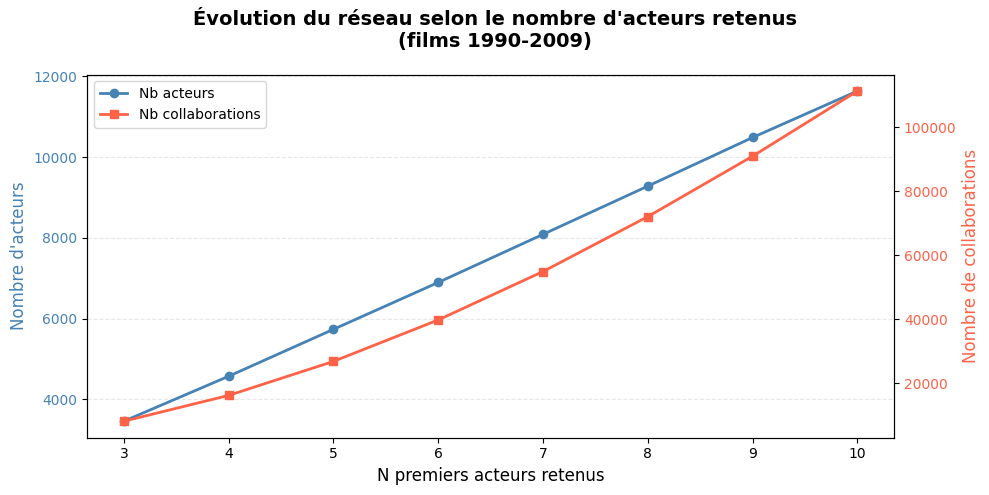

In [ ]:
df_stats = pd.DataFrame(stats)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Axe gauche : nombre d'acteurs
ax1.plot(df_stats['nb_actor'], df_stats['acteurs'], color='steelblue', marker='o', linewidth=2, label="Nb acteurs")
ax1.set_xlabel("N premiers acteurs retenus", fontsize=12)
ax1.set_ylabel("Nombre d'acteurs", color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')

# Axe droit : nombre de collaborations
ax2 = ax1.twinx()
ax2.plot(df_stats['nb_actor'], df_stats['collabs'], 
         color='tomato', marker='s', linewidth=2, label="Nb collaborations")
ax2.set_ylabel("Nombre de collaborations", color='tomato', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tomato')

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_xticks(df_stats['nb_actor'])
ax1.grid(axis='y', alpha=0.3, linestyle='--')
fig.suptitle("Évolution du réseau selon le nombre d'acteurs retenus\n(films 1990-2009)", 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

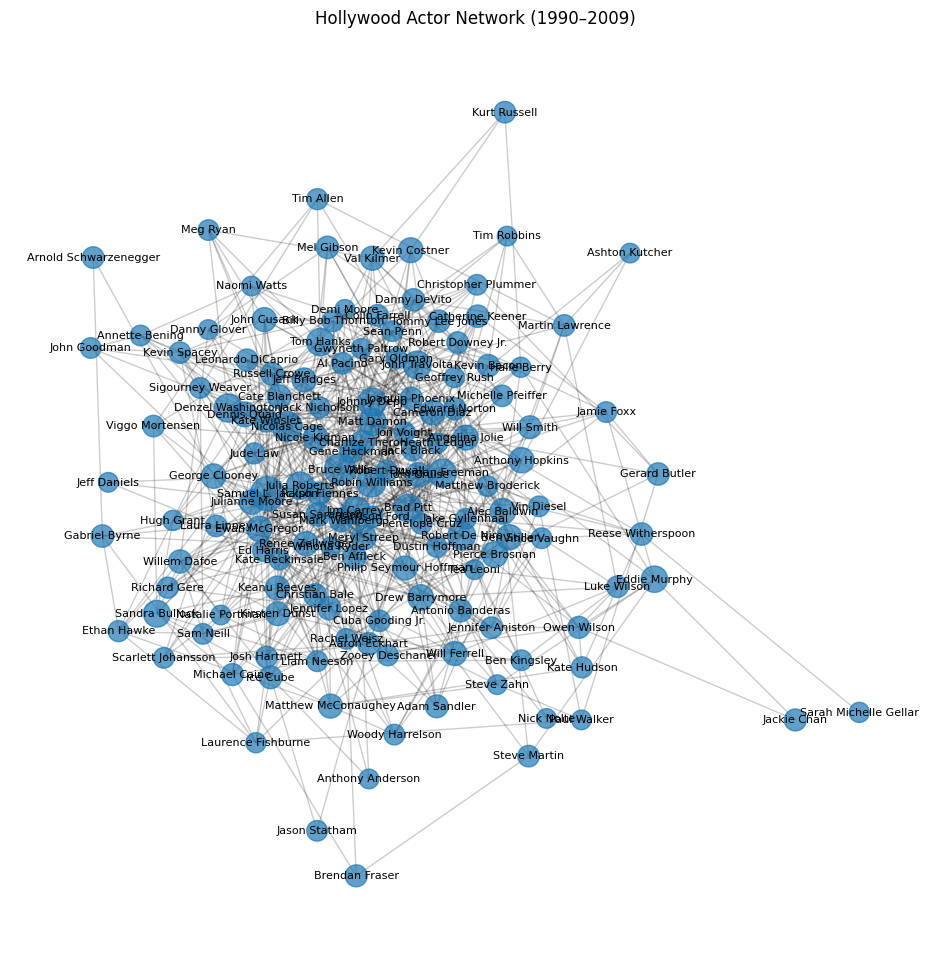

In [8]:
# Afficher graph avec 3 acteurs
G = get_imdb_graph(data, nbr_actors=3, firstyear=1990, lastyear=2009)

# Calcul du degré (nombre de connexions)
degree_dict = dict(G.degree())

# Garder les acteurs avec au moins 20 connexions
filtered_nodes = [node for node, deg in degree_dict.items() if deg >= 20]

subG = G.subgraph(filtered_nodes)

plt.figure(figsize=(12,12))
pos = nx.spring_layout(subG, k=0.3)

nx.draw_networkx_nodes(subG, pos, 
                       node_size=[degree_dict[n]*10 for n in subG.nodes()],
                       alpha=0.7)

nx.draw_networkx_edges(subG, pos, alpha=0.2)

nx.draw_networkx_labels(subG, pos, font_size=8)

plt.title("Hollywood Actor Network (1990–2009)")
plt.axis("off")
plt.show()

### Centralité des acteurs

Degree → nombre de co-acteurs

Betweenness → se lit comme "X% des chemins du réseau passent par cet acteur"

PageRank → rang (1 = le plus influent)

In [9]:
G = get_imdb_graph(data, nbr_actors=3, firstyear=1990, lastyear=2009)

# Degree : nombre brut de co-acteurs au lieu du ratio normalisé
degree_raw        = dict(G.degree())
betweenness       = nx.betweenness_centrality(G)
pagerank          = nx.pagerank(G)

df_centrality = pd.DataFrame({
    'actor'             : list(degree_raw.keys()),
    'nb_coacteurs'      : list(degree_raw.values()),                          # nombre brut
    'betweenness_pct'   : [round(betweenness[a] * 100, 2) for a in degree_raw],  # en %
    'pagerank_rank'     : [pagerank[a] for a in degree_raw]
})

# Ajouter le rang PageRank (1 = le plus influent)
df_centrality['pagerank_rang'] = df_centrality['pagerank_rank'].rank(ascending=False).astype(int)
df_centrality = df_centrality.sort_values('nb_coacteurs', ascending=False)

print("=== Top 10 par co-acteurs directs ===")
print(df_centrality.nlargest(10, 'nb_coacteurs')
      [['actor', 'nb_coacteurs', 'pagerank_rang']].to_string(index=False))

print("\n=== Top 10 ponts du réseau (betweenness) ===")
print(df_centrality.nlargest(10, 'betweenness_pct')
      [['actor', 'betweenness_pct', 'nb_coacteurs']]
      .rename(columns={'betweenness_pct': '% chemins passant par cet acteur'})
      .to_string(index=False))

print("\n=== Top 10 par PageRank (rang) ===")
print(df_centrality.nsmallest(10, 'pagerank_rang')
      [['actor', 'pagerank_rang', 'nb_coacteurs']].to_string(index=False))

# Stats globales pour contextualiser
print(f"\n=== Contexte du réseau ===")
print(f"Nombre total d'acteurs       : {G.number_of_nodes():,}")
print(f"Nombre total de liens        : {G.number_of_edges():,}")
print(f"Moyenne de co-acteurs/acteur : {sum(degree_raw.values()) / len(degree_raw):.1f}")

=== Top 10 par co-acteurs directs ===
            actor  nb_coacteurs  pagerank_rang
Samuel L. Jackson            60              1
     Bruce Willis            51              2
     Nicolas Cage            46              3
   Robin Williams            44              4
Denzel Washington            41              5
   Morgan Freeman            41              9
      Johnny Depp            41             12
   Robert De Niro            40             11
    John Travolta            40             13
        Brad Pitt            39             15

=== Top 10 ponts du réseau (betweenness) ===
            actor  % chemins passant par cet acteur  nb_coacteurs
Samuel L. Jackson                              2.60            60
     Bruce Willis                              2.32            51
       Matt Damon                              1.52            38
        Tom Hanks                              1.50            39
Denzel Washington                              1.35            41
   

### Varier les n premiers acteurs

In [18]:
for nb_actor in range(3, 11) : 
    print(f"\nPour les {nb_actor} premiers acteurs : ")
    G = get_imdb_graph(data, nbr_actors=nb_actor, firstyear=1990, lastyear=2009)

    # Degree : nombre brut de co-acteurs au lieu du ratio normalisé
    degree_raw        = dict(G.degree())
    betweenness       = nx.betweenness_centrality(G)
    pagerank          = nx.pagerank(G)

    df_centrality = pd.DataFrame({
        'actor'             : list(degree_raw.keys()),
        'nb_coacteurs'      : list(degree_raw.values()),                          # nombre brut
        'betweenness_pct'   : [round(betweenness[a] * 100, 2) for a in degree_raw],  # en %
        'pagerank_rank'     : [pagerank[a] for a in degree_raw]
    })

    # Ajouter le rang PageRank (1 = le plus influent)
    df_centrality['pagerank_rang'] = df_centrality['pagerank_rank'].rank(ascending=False).astype(int)
    df_centrality = df_centrality.sort_values('nb_coacteurs', ascending=False)

    print("=== Top 3 par co-acteurs directs ===")
    print(df_centrality.nlargest(3, 'nb_coacteurs')
        [['actor', 'nb_coacteurs', 'pagerank_rang']].to_string(index=False))

    print("\n=== Top 3 ponts du réseau (betweenness) ===")
    print(df_centrality.nlargest(3, 'betweenness_pct')
        [['actor', 'betweenness_pct', 'nb_coacteurs']]
        .rename(columns={'betweenness_pct': '% chemins passant par cet acteur'})
        .to_string(index=False))

    print("\n=== Top 3 par PageRank (rang) ===")
    print(df_centrality.nsmallest(3, 'pagerank_rang')
        [['actor', 'pagerank_rang', 'nb_coacteurs']].to_string(index=False))

    # Stats globales pour contextualiser
    print(f"\n=== Contexte du réseau ===")
    print(f"Nombre total d'acteurs       : {G.number_of_nodes():,}")
    print(f"Nombre total de liens        : {G.number_of_edges():,}")
    print(f"Moyenne de co-acteurs/acteur : {sum(degree_raw.values()) / len(degree_raw):.1f}\n")

Pour les 3 premiers acteurs : 
=== Top 3 par co-acteurs directs ===
            actor  nb_coacteurs  pagerank_rang
Samuel L. Jackson            60              1
     Bruce Willis            51              2
     Nicolas Cage            46              3

=== Top 3 ponts du réseau (betweenness) ===
            actor  % chemins passant par cet acteur  nb_coacteurs
Samuel L. Jackson                              2.60            60
     Bruce Willis                              2.32            51
       Matt Damon                              1.52            38

=== Top 3 par PageRank (rang) ===
            actor  pagerank_rang  nb_coacteurs
Samuel L. Jackson              1            60
     Bruce Willis              2            51
     Nicolas Cage              3            46

=== Contexte du réseau ===
Nombre total d'acteurs       : 3,455
Nombre total de liens        : 8,119
Moyenne de co-acteurs/acteur : 4.7
Pour les 4 premiers acteurs : 
=== Top 3 par co-acteurs directs ===
       

---
### Chemin le plus court entre deux acteurs

In [ ]:
G = get_imdb_graph(data, nbr_actors=3, firstyear=1990, lastyear=2009)

def shortest_path_between(G, actor1, actor2) :
    try:
        path = nx.shortest_path(G, source=actor1, target=actor2)
        print(f"Chemin entre '{actor1}' et '{actor2}' ({len(path)-1} degrés) :")
        for i, actor in enumerate(path):
            print(f"  {'→ ' if i > 0 else ''}{actor}")
    except nx.NetworkXNoPath:
        print(f"Aucun chemin trouvé entre '{actor1}' et '{actor2}'")
    except nx.NodeNotFound as e:
        print(f"Acteur introuvable : {e}")

# Exemple
shortest_path_between(G, "Kevin Bacon", "Tom Hanks")
shortest_path_between(G, "Brad Pitt", "Meryl Streep")

# Distance moyenne dans tout le graphe (sur la composante principale)
largest_cc = G.subgraph(max(nx.connected_components(G), key=len))
avg_path = nx.average_shortest_path_length(largest_cc)
print(f"\nDistance moyenne entre deux acteurs : {avg_path:.2f}\n")

# Trouver l'acteur qui est le plus proche de TOUT le monde = le vrai "centre" du réseau

closeness = nx.closeness_centrality(largest_cc)
df_closeness = pd.Series(closeness).sort_values(ascending=False)

print("=== Top 10 acteurs les plus proches de tout le réseau ===")
for actor, score in df_closeness.head(10).items():
    avg_distance = 1 / score  # inverse de la closeness
    print(f"{actor:<25} : distance moyenne {avg_distance:.2f} degrés")

# Vérifier le phénomène petit monde
print(f"\n=== Phénomène petit monde ===")
print(f"Distance moyenne        : {nx.average_shortest_path_length(largest_cc):.2f}")
print(f"Coefficient de clustering: {nx.average_clustering(largest_cc):.4f}")
# Un vrai réseau petit monde a une distance moyenne faible ET un clustering élevé
# Clustering proche de 1 = les amis de mes amis sont aussi mes amis

Chemin entre 'Kevin Bacon' et 'Tom Hanks' (1 degrés) :
  Kevin Bacon
  → Tom Hanks
Chemin entre 'Brad Pitt' et 'Meryl Streep' (2 degrés) :
  Brad Pitt
  → Kevin Bacon
  → Meryl Streep

Distance moyenne entre deux acteurs : 4.62

=== Top 10 acteurs les plus proches de tout le réseau ===
Samuel L. Jackson         : distance moyenne 3.14 degrés
Bruce Willis              : distance moyenne 3.17 degrés
Julia Roberts             : distance moyenne 3.25 degrés
Meryl Streep              : distance moyenne 3.25 degrés
Nicolas Cage              : distance moyenne 3.27 degrés
Robin Williams            : distance moyenne 3.27 degrés
Cameron Diaz              : distance moyenne 3.28 degrés
Robert De Niro            : distance moyenne 3.28 degrés
Morgan Freeman            : distance moyenne 3.29 degrés
John Travolta             : distance moyenne 3.29 degrés

=== Phénomène petit monde ===
Distance moyenne        : 4.62
Coefficient de clustering: 0.6207


### Variation n acteurs

In [20]:
for nb_actor in range(3, 11) : 
    print(f"\nPour les {nb_actor} premiers acteurs : ")
    G = get_imdb_graph(data, nbr_actors=nb_actor, firstyear=1990, lastyear=2009)

    def shortest_path_between(G, actor1, actor2) :
        try:
            path = nx.shortest_path(G, source=actor1, target=actor2)
            print(f"Chemin entre '{actor1}' et '{actor2}' ({len(path)-1} degrés) :")
            for i, actor in enumerate(path):
                print(f"  {'→ ' if i > 0 else ''}{actor}")
        except nx.NetworkXNoPath :
            print(f"Aucun chemin trouvé entre '{actor1}' et '{actor2}'")
        except nx.NodeNotFound as e :
            print(f"Acteur introuvable : {e}")

    # Distance moyenne dans tout le graphe (sur la composante principale)
    largest_cc = G.subgraph(max(nx.connected_components(G), key=len))
    avg_path = nx.average_shortest_path_length(largest_cc)
    print(f"\nDistance moyenne entre deux acteurs : {avg_path:.2f}\n")

    # Trouver l'acteur qui est le plus proche de TOUT le monde = le vrai "centre" du réseau

    closeness = nx.closeness_centrality(largest_cc)
    df_closeness = pd.Series(closeness).sort_values(ascending=False)

    print("=== Top 3 acteurs les plus proches de tout le réseau ===")
    for actor, score in df_closeness.head(3).items():
        avg_distance = 1 / score  # inverse de la closeness
        print(f"{actor:<25} : distance moyenne {avg_distance:.2f} degrés")

    # Vérifier le phénomène petit monde
    print(f"\n=== Phénomène petit monde ===")
    print(f"Distance moyenne        : {nx.average_shortest_path_length(largest_cc):.2f}")
    print(f"Coefficient de clustering: {nx.average_clustering(largest_cc):.4f}\n")
    # Un vrai réseau petit monde a une distance moyenne faible ET un clustering élevé
    # Clustering proche de 1 = les amis de mes amis sont aussi mes amis


Pour les 3 premiers acteurs : 

Distance moyenne entre deux acteurs : 4.62

=== Top 3 acteurs les plus proches de tout le réseau ===
Samuel L. Jackson         : distance moyenne 3.14 degrés
Bruce Willis              : distance moyenne 3.17 degrés
Julia Roberts             : distance moyenne 3.25 degrés

=== Phénomène petit monde ===
Distance moyenne        : 4.62
Coefficient de clustering: 0.6207


Pour les 4 premiers acteurs : 

Distance moyenne entre deux acteurs : 4.24

=== Top 3 acteurs les plus proches de tout le réseau ===
Samuel L. Jackson         : distance moyenne 2.96 degrés
Robert De Niro            : distance moyenne 2.98 degrés
Bruce Willis              : distance moyenne 2.98 degrés

=== Phénomène petit monde ===
Distance moyenne        : 4.24
Coefficient de clustering: 0.6731


Pour les 5 premiers acteurs : 

Distance moyenne entre deux acteurs : 4.01

=== Top 3 acteurs les plus proches de tout le réseau ===
Samuel L. Jackson         : distance moyenne 2.82 degrés
Rober

---
### Paires d'acteurs courants

In [11]:
G_weighted = nx.Graph()

# Filtrer par année
data['release_date'] = pd.to_datetime(data['release_date'], errors='coerce')
data_filtered = data[
    (data['release_date'].dt.year >= 1990) &
    (data['release_date'].dt.year <= 2009)
]

for _, row in data_filtered.iterrows() :
    try :
        actors = get_top_actors(row['cast'], nbr=3)
        actors = [a for a in actors if pd.notna(a)]
        for i in range(len(actors)):
            for j in range(i + 1, len(actors)):
                if G_weighted.has_edge(actors[i], actors[j]) :
                    G_weighted[actors[i]][actors[j]]['weight'] += 1
                    G_weighted[actors[i]][actors[j]]['films'].append(row['original_title'])
                else :
                    G_weighted.add_edge(actors[i], actors[j], weight=1, films=[row['original_title']])
    except :
        pass

# Extraire les paires avec leur poids et leurs films
edges_df = pd.DataFrame([
    {
        'actor1'        : u,
        'actor2'        : v,
        'films_ensemble': d['weight'],
        'films'         : d['films']
    }
    for u, v, d in G_weighted.edges(data=True)
]).sort_values('films_ensemble', ascending=False)

print("=== Top 15 des duos les plus fréquents ===")
for _, row in edges_df.head(15).iterrows():
    print(f"\n{row['actor1']} & {row['actor2']} ({row['films_ensemble']} films) :")
    for film in row['films']:
        print(f"  → {film}")

=== Top 15 des duos les plus fréquents ===

Daniel Radcliffe & Rupert Grint (6 films) :
  → Harry Potter and the Half-Blood Prince
  → Harry Potter and the Order of the Phoenix
  → Harry Potter and the Goblet of Fire
  → Harry Potter and the Prisoner of Azkaban
  → Harry Potter and the Philosopher's Stone
  → Harry Potter and the Chamber of Secrets

Daniel Radcliffe & Emma Watson (6 films) :
  → Harry Potter and the Half-Blood Prince
  → Harry Potter and the Order of the Phoenix
  → Harry Potter and the Goblet of Fire
  → Harry Potter and the Prisoner of Azkaban
  → Harry Potter and the Philosopher's Stone
  → Harry Potter and the Chamber of Secrets

Rupert Grint & Emma Watson (6 films) :
  → Harry Potter and the Half-Blood Prince
  → Harry Potter and the Order of the Phoenix
  → Harry Potter and the Goblet of Fire
  → Harry Potter and the Prisoner of Azkaban
  → Harry Potter and the Philosopher's Stone
  → Harry Potter and the Chamber of Secrets

Patrick Stewart & Jonathan Frakes (4 f

### Varier n

In [19]:
for nb_actor in range(3, 11) : 
    print(f"\nPour les {nb_actor} premiers acteurs : ")
    G_weighted = nx.Graph()

    # Filtrer par année
    data['release_date'] = pd.to_datetime(data['release_date'], errors='coerce')
    data_filtered = data[
        (data['release_date'].dt.year >= 1990) &
        (data['release_date'].dt.year <= 2009)
    ]

    for _, row in data_filtered.iterrows() :
        try :
            actors = get_top_actors(row['cast'], nbr=nb_actor)
            actors = [a for a in actors if pd.notna(a)]
            for i in range(len(actors)):
                for j in range(i + 1, len(actors)):
                    if G_weighted.has_edge(actors[i], actors[j]) :
                        G_weighted[actors[i]][actors[j]]['weight'] += 1
                        G_weighted[actors[i]][actors[j]]['films'].append(row['original_title'])
                    else :
                        G_weighted.add_edge(actors[i], actors[j], weight=1, films=[row['original_title']])
        except :
            pass

    # Extraire les paires avec leur poids et leurs films
    edges_df = pd.DataFrame([
        {
            'actor1'        : u,
            'actor2'        : v,
            'films_ensemble': d['weight'],
            'films'         : d['films']
        }
        for u, v, d in G_weighted.edges(data=True)
    ]).sort_values('films_ensemble', ascending=False)

    print("=== Top 3 des duos les plus fréquents ===")
    for _, row in edges_df.head(3).iterrows():
        print(f"\n{row['actor1']} & {row['actor2']} ({row['films_ensemble']} films) ")
        """for film in row['films']:
            print(f"  → {film}")"""


Pour les 3 premiers acteurs : 
=== Top 3 des duos les plus fréquents ===

Daniel Radcliffe & Rupert Grint (6 films) 

Daniel Radcliffe & Emma Watson (6 films) 

Rupert Grint & Emma Watson (6 films) 

Pour les 4 premiers acteurs : 
=== Top 3 des duos les plus fréquents ===

Rupert Grint & Emma Watson (6 films) 

Daniel Radcliffe & Rupert Grint (6 films) 

Daniel Radcliffe & Emma Watson (6 films) 

Pour les 5 premiers acteurs : 
=== Top 3 des duos les plus fréquents ===

Daniel Radcliffe & Rupert Grint (6 films) 

Daniel Radcliffe & Emma Watson (6 films) 

Rupert Grint & Emma Watson (6 films) 

Pour les 6 premiers acteurs : 
=== Top 3 des duos les plus fréquents ===

Daniel Radcliffe & Rupert Grint (6 films) 

Daniel Radcliffe & Emma Watson (6 films) 

Rupert Grint & Emma Watson (6 films) 

Pour les 7 premiers acteurs : 
=== Top 3 des duos les plus fréquents ===

Daniel Radcliffe & Emma Watson (6 films) 

Daniel Radcliffe & Rupert Grint (6 films) 

Rupert Grint & Emma Watson (6 films) 


---
### Evolution du reseau dans le temps

In [12]:
decades = range(1960, 2020, 10)  # de 1960 à 2010

stats = []
for decade in decades:
    G_decade = get_imdb_graph(data, nbr_actors=3, firstyear=decade, lastyear=decade+9)
    
    if G_decade.number_of_nodes() == 0:
        continue
    
    largest_cc = G_decade.subgraph(max(nx.connected_components(G_decade), key=len))
    
    stats.append({
        'decade'        : f"{decade}s",
        'nb_acteurs'    : G_decade.number_of_nodes(),
        'nb_liens'      : G_decade.number_of_edges(),
        'densite'       : round(nx.density(G_decade), 4),
        'composante_principale' : largest_cc.number_of_nodes()
    })

df_evolution = pd.DataFrame(stats)
print(df_evolution.to_string(index=False))

decade  nb_acteurs  nb_liens  densite  composante_principale
 1960s         182       213   0.0129                     17
 1970s         264       325   0.0094                     56
 1980s         633       807   0.0040                    228
 1990s        1238      2294   0.0030                    939
 2000s        2835      5889   0.0015                   1962
 2010s        2389      4139   0.0015                   1425
